In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, LinearAlgebra;

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [3]:
HwannierUp, cell_mapUp = hwannier("wannierUp"), np.loadtxt("wannierUp.map.txt");
HwannierDn, cell_mapDn = hwannier("wannierDn"), np.loadtxt("wannierDn.map.txt");

In [5]:
EsUp, _ = wannier_bands(HwannierUp, cell_mapUp, hcat(bandstructkpoints2q(kpointsfile="../bandstruct.kpoints")...));
EsDn, _ = wannier_bands(HwannierDn, cell_mapDn, hcat(bandstructkpoints2q(kpointsfile="../bandstruct.kpoints")...));

In [6]:
np.savetxt("EsUp.txt", EsUp)
np.savetxt("EsDn.txt", EsDn)

In [7]:
EnergiesUp, DOSUp = density_of_states(HwannierUp, cell_mapUp, Val(2), histogram_width=1000, mesh=20, monte_carlo=true, num_blocks=100)
EnergiesDn, DOSDn = density_of_states(HwannierDn, cell_mapDn, Val(2), histogram_width=1000, mesh=20, monte_carlo=true, num_blocks=100)

([-24.57223067129581, -24.5712306658843, -24.570230660472795, -24.569230655061286, -24.568230649649777, -24.567230644238272, -24.566230638826763, -24.565230633415254, -24.56423062800375, -24.56323062259224  …  5.370931365480455, 5.371931370891964, 5.37293137630347, 5.3739313817149785, 5.374931387126487, 5.375931392537993, 5.376931397949502, 5.377931403361011, 5.378931408772516, 5.379931414184025], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

In [8]:
np.savetxt("DosUp.txt", hcat(EnergiesUp, DOSUp))
np.savetxt("DosDn.txt", hcat(EnergiesDn, DOSDn))

In [4]:
epsilons = zeros(100, 100);
kpoints = bandstructkpoints2q(interpolate=5);
lattice_vectors = loadlattice("./wannier.out")
energies = collect(range(0, 100, length=100*1000));
landau_lower = zeros(80);
landau_upper = zeros(80);

In [6]:
for (i, k) in enumerate(kpoints[1:100])
    #println(i); flush(stdout)
    i == 1 && continue
    polarization = parse.(Float64, readlines("Plasmon.out-$i"))
    for (j, ω) in enumerate(range(0.05, 0.5, length=100))
        epsilons[i, j] = imag(1 / ϵ(k, lattice_vectors, ω, energies, polarization, δ=0.001))
    end
end

In [7]:
plasmon = [range(0.05, 0.5, length=100)[argmax(x)] for x in eachrow(log.(abs.(epsilons[2:80, :])))];
plasmon = [0, plasmon...]
qs, confinements = confinement(lattice_vectors, kpoints[1:80], plasmon)
confinements[1] = 0;
plasmon = smooth(plasmon, win_len=20)
confinements = smooth(confinements, win_len=10);

In [9]:
for (i, k) in enumerate(kpoints[1:80])
    polarizations = parse.(Float64, readlines("Plasmon.out-$i"))
    non_zero_impols = energies[findall(.!iszero.(polarizations))]
    landau_lower[i] = maximum([filter(x-> x < plasmon[i], non_zero_impols)..., 0])
    landau_upper[i] = minimum(filter(x-> x > plasmon[i], non_zero_impols))
end

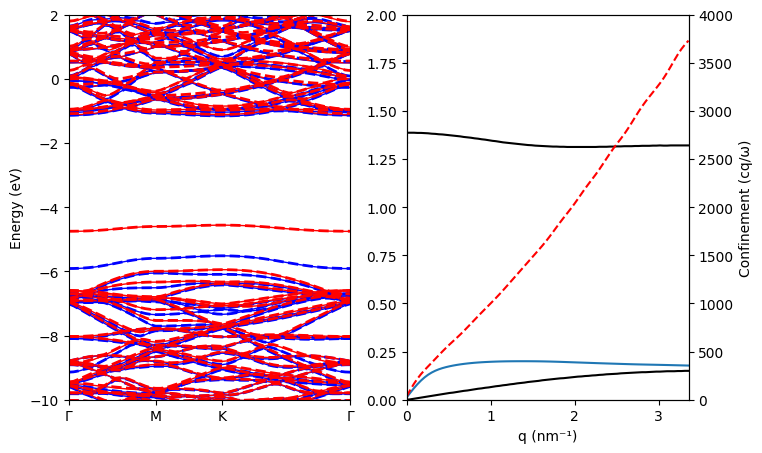

PyObject Text(0.5, 0, 'q (nm⁻¹)')

In [11]:
figure(figsize=(8, 5))

subplot(1, 2, 1)
plot_bands("../BN44NC.bands.eigenvals", kpointsfile = "../bandstruct.kpoints", spin=2, linewidth=1, to_greek=true)
plot_bands(HwannierUp, cell_mapUp, kpointsfile="../bandstruct.kpoints", linewidth=2, color="blue", linestyle="dashed")
plot_bands(HwannierDn, cell_mapDn, kpointsfile="../bandstruct.kpoints", linewidth=2, color="red", linestyle="dashed")
xlabel("")
ylim(-10, 2)

subplot(1, 2, 2)
plot(qs*10, plasmon)
plot(qs*10, landau_lower, color="black")
plot(qs*10, landau_upper, color="black")

xlabel("q (nm⁻¹)")
ylim(0, 2)
#ylim(0, 0.25)
twinx()
plot(qs*10, confinements, color="red", linestyle="dashed")
ylim(0, 4000)
xlabel("q (nm⁻¹)")
xlim(0, maximum(qs)*10)
ylabel("Confinement (cq/ω)")

xlabel("q (nm⁻¹)")
#savefig("BN44NC-Plasmon.pdf")

In [25]:
np.savetxt("Plasmon.txt", hcat(qs, plasmon, confinements))

In [12]:
np.savetxt("Landau.txt", hcat(qs, landau_lower, landau_upper))

In [26]:
qs, plasmon, confinements = [x for x in eachcol(np.loadtxt("Plasmon.txt"))];

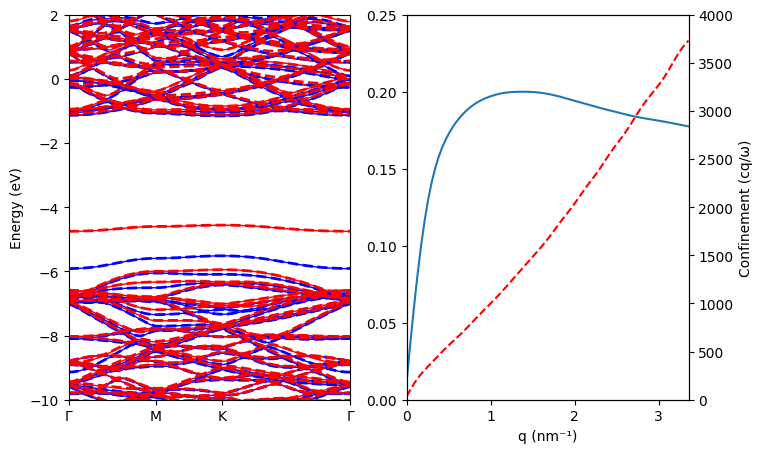

PyObject Text(0.5, 0, 'q (nm⁻¹)')

In [27]:
figure(figsize=(8, 5))

subplot(1, 2, 1)
plot_bands("../BN44NC.bands.eigenvals", kpointsfile = "../bandstruct.kpoints", spin=2, linewidth=1, to_greek=true)
plot_bands(HwannierUp, cellmapUp, kpointsfile="../bandstruct.kpoints", linewidth=2, color="blue", linestyle="dashed")
plot_bands(HwannierDn, cellmapDn, kpointsfile="../bandstruct.kpoints", linewidth=2, color="red", linestyle="dashed")
xlabel("")
ylim(-10, 2)

subplot(1, 2, 2)
plot(qs*10, plasmon)
xlabel("q (nm⁻¹)")
ylim(0, 0.25)
twinx()
plot(qs*10, confinements, color="red", linestyle="dashed")
ylim(0, 4000)
xlabel("q (nm⁻¹)")
xlim(0, maximum(qs)*10)
ylabel("Confinement (cq/ω)")

xlabel("q (nm⁻¹)")
#savefig("BN44NC-Plasmon.pdf")